In [2]:
# import sys
# print(sys.executable)
# ---- referencias bibliográficas ----
# YURI MACHADO DE SOUZA (orient.). Modelo de regressão logística binária aplicada a dados de acidentes em rodovias federais no Brasil. Piracicaba, SP: ESALQ/USP, 2022. Trabalho de Conclusão de Curso. (Trabalhos de Conclusão de Curso).



In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from scipy.stats import ttest_ind, mannwhitneyu
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb
import joblib

In [4]:
#  referencia do dataset 
# https://www.kaggle.com/datasets/ricardotorresheredia/nba-stats-from-the-last-71-years
# https://ge.globo.com/basquete/nba/noticia/2024/06/18/campeoes-da-nba-confira-os-vencedores-de-todas-as-edicoes-e-curiosidades.ghtml
# analise "de trás para frente" dos campeões da NBA https://poe.com/s/76HKJVmPILjk7unQiVMj
# sigla com o nome dos times https://poe.com/s/EYzHbWvL5owhCOO7Vvqq
# fonte com a siglas dos times https://poe.com/s/Nmf2dGW7fN0YeMiHSe2V


In [5]:
# Criar um dataframe com os campeões e vice-campeões
champions_data = [
    (1989, 'Detroit Pistons', 'Los Angeles Lakers'),
    (1990, 'Detroit Pistons', 'Portland Trail Blazers'),
    (1991, 'Chicago Bulls', 'Los Angeles Lakers'),
    (1992, 'Chicago Bulls', 'Portland Trail Blazers'),
    (1993, 'Chicago Bulls', 'Phoenix Suns'),
    (1994, 'Houston Rockets', 'New York Knicks'),
    (1995, 'Houston Rockets', 'Orlando Magic'),
    (1996, 'Chicago Bulls', 'Seattle SuperSonics'),
    (1997, 'Chicago Bulls', 'Utah Jazz'),
    (1998, 'Chicago Bulls', 'Utah Jazz'),
    (1999, 'San Antonio Spurs', 'New York Knicks'),
    (2000, 'Los Angeles Lakers', 'Indiana Pacers'),
    (2001, 'Los Angeles Lakers', 'Philadelphia 76ers'),
    (2002, 'Los Angeles Lakers', 'New Jersey Nets'),
    (2003, 'San Antonio Spurs', 'New Jersey Nets'),
    (2004, 'Detroit Pistons', 'Los Angeles Lakers'),
    (2005, 'San Antonio Spurs', 'Detroit Pistons'),
    (2006, 'Miami Heat', 'Dallas Mavericks'),
    (2007, 'San Antonio Spurs', 'Cleveland Cavaliers'),
    (2008, 'Boston Celtics', 'Los Angeles Lakers'),
    (2009, 'Los Angeles Lakers', 'Orlando Magic'),
    (2010, 'Los Angeles Lakers', 'Boston Celtics'),
    (2011, 'Dallas Mavericks', 'Miami Heat'),
    (2012, 'Miami Heat', 'Oklahoma City Thunder'),
    (2013, 'Miami Heat', 'San Antonio Spurs'),
    (2014, 'San Antonio Spurs', 'Miami Heat'),
    (2015, 'Golden State Warriors', 'Cleveland Cavaliers'),
    (2016, 'Cleveland Cavaliers', 'Golden State Warriors'),
    (2017, 'Golden State Warriors', 'Cleveland Cavaliers'),
    (2018, 'Golden State Warriors', 'Cleveland Cavaliers'),
    (2019, 'Toronto Raptors', 'Golden State Warriors'),
    (2020, 'Los Angeles Lakers', 'Miami Heat'),
    (2021, 'Milwaukee Bucks', 'Phoenix Suns'),
    (2022, 'Golden State Warriors', 'Boston Celtics'),
]

# Transformar os dados em um dataframe
champions_df = pd.DataFrame(champions_data, columns=['Year', 'Champion', 'Runner-Up'])

In [6]:
champions_df

,Year,Champion,Runner-Up
0,1989,Detroit Pistons,Los Angeles Lakers
1,1990,Detroit Pistons,Portland Trail Blazers
2,1991,Chicago Bulls,Los Angeles Lakers
3,1992,Chicago Bulls,Portland Trail Blazers
4,1993,Chicago Bulls,Phoenix Suns
5,1994,Houston Rockets,New York Knicks
6,1995,Houston Rockets,Orlando Magic
7,1996,Chicago Bulls,Seattle SuperSonics
8,1997,Chicago Bulls,Utah Jazz
9,1998,Chicago Bulls,Utah Jazz


In [7]:
# Caminho do arquivo .ods
caminho_pasta = r"C:\Users\aoliveira_esss\Desktop\projeto_nba\NBA\NBA_Stats_71_Years_Updated.xlsx"
abreviacao = r"C:\Users\aoliveira_esss\Desktop\projeto_nba\NBA\abreviacao_times.csv"

# Carregar o arquivo .ods em um DataFrame
df_nba = pd.read_excel(caminho_pasta)
df_abreviacao = pd.read_csv(abreviacao, encoding="utf-8", sep=",")

# Exibir as primeiras linhas para verificar
df_nba.head()

,Rank,Year,Season Start Year,Season Type,Player ID,Player,Team ID,Team,Games Played,Minutes Played,...,Rebounds,Assists,Steals,Blocks,Turnovers,Personal Fouls,Points Scored,Efficency,AST/TOV,STL/TOV
0,1,1951-52,1951,Regular Season,76056,Paul Arizin,1610612744,PHW,66,2939,...,745,170,NaN,NaN,NaN,250,1674,1786,NaN,NaN
1,2,1951-52,1951,Regular Season,600012,George Mikan,1610612747,MNL,64,2572,...,866,194,NaN,NaN,NaN,286,1523,1592,NaN,NaN
2,3,1951-52,1951,Regular Season,600003,Bob Cousy,1610612738,BOS,66,2681,...,421,441,NaN,NaN,NaN,190,1433,1322,NaN,NaN
3,4,1951-52,1951,Regular Season,77429,Ed Macauley,1610612738,BOS,66,2631,...,529,232,NaN,NaN,NaN,174,1264,1396,NaN,NaN
4,5,1951-52,1951,Regular Season,76514,Bob Davies,1610612758,ROC,65,2394,...,189,390,NaN,NaN,NaN,269,1052,935,NaN,NaN


In [8]:
# Criar um dicionário para mapear Abreviação -> Nome do Time
team_name_mapping = dict(zip(df_abreviacao['Abreviação'], df_abreviacao['Nome do Time']))

# Exibir o dicionário para verificar
# print(team_name_mapping)

In [9]:
ano_de_corte = 1990
df_nba_1990 = df_nba[df_nba['Season Start Year'] >= ano_de_corte]



- fonte com a lista de cada abreviacao e o nome do time
https://www.apbr.org/abbreviations.html


In [10]:
# Adicionar a coluna "Team Full Name"
df_nba_1990['Team Full Name'] = df_nba_1990['Team'].map(team_name_mapping)

# Verificar o resultado
print(df_nba_1990[['Team', 'Team Full Name']].head())

      Team         Team Full Name
11569  CHI          Chicago Bulls
11570  UTH              Utah Jazz
11571  NYK        New York Knicks
11572  GOS  Golden State Warriors
11573  SAN      San Antonio Spurs


C:\Users\aoliveira_esss\AppData\Local\Temp\ipykernel_17180\2266917709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nba_1990['Team Full Name'] = df_nba_1990['Team'].map(team_name_mapping)


In [11]:
# verificar valores ausentes
valores_ausentes = df_nba_1990.isnull().sum()
valores_ausentes

Rank                  0
Year                  0
Season Start Year     0
Season Type           0
Player ID             0
Player                0
Team ID               0
Team                  0
Games Played          0
Minutes Played        0
FG Made               0
FG Attempts           0
FG %                  0
3-Pt FG Made          0
3-Pt FG Attempts      0
3-Pt FG %             0
FT Made               0
FT Attempts           0
FT %                  0
Offensive Rebounds    0
Defensive Rebounds    0
Rebounds              0
Assists               0
Steals                0
Blocks                0
Turnovers             0
Personal Fouls        0
Points Scored         0
Efficency             0
AST/TOV               0
STL/TOV               0
Team Full Name        0
dtype: int64

In [12]:
# calcular a porcentagem de valores ausentes
porcentagem_ausentes = (valores_ausentes / len(df_nba_1990)) * 100
porcentagem_ausentes

Rank                  0.0
Year                  0.0
Season Start Year     0.0
Season Type           0.0
Player ID             0.0
Player                0.0
Team ID               0.0
Team                  0.0
Games Played          0.0
Minutes Played        0.0
FG Made               0.0
FG Attempts           0.0
FG %                  0.0
3-Pt FG Made          0.0
3-Pt FG Attempts      0.0
3-Pt FG %             0.0
FT Made               0.0
FT Attempts           0.0
FT %                  0.0
Offensive Rebounds    0.0
Defensive Rebounds    0.0
Rebounds              0.0
Assists               0.0
Steals                0.0
Blocks                0.0
Turnovers             0.0
Personal Fouls        0.0
Points Scored         0.0
Efficency             0.0
AST/TOV               0.0
STL/TOV               0.0
Team Full Name        0.0
dtype: float64

In [13]:
# exibir colunas com valores ausentes
colunas_ausentes = porcentagem_ausentes[porcentagem_ausentes > 0]
colunas_ausentes

Series([], dtype: float64)

In [14]:
# Adicionar colunas 'Champion Team' e 'Runner-Up Team' usando Team Full Name
def mark_championship(row):
    year = row['Season Start Year']
    team_full_name = row['Team Full Name']

    # Verificar se o ano e o nome completo da equipe correspondem ao campeão ou vice-campeão
    if year in champions_df['Year'].values:
        champion_team = champions_df.loc[champions_df['Year'] == year, 'Champion'].values[0]
        runner_up_team = champions_df.loc[champions_df['Year'] == year, 'Runner-Up'].values[0]
        
        if team_full_name == champion_team:
            return 'Champion'
        elif team_full_name == runner_up_team:
            return 'Runner-Up'
    return 'Other'

# Aplicar a função para criar uma nova coluna 'Team Status'
df_nba_1990['Team Status'] = df_nba_1990.apply(mark_championship, axis=1)

# Converter 'Team Status' em colunas binárias
df_nba_1990['Champion'] = (df_nba_1990['Team Status'] == 'Champion').astype(int)
df_nba_1990['Runner-Up'] = (df_nba_1990['Team Status'] == 'Runner-Up').astype(int)

C:\Users\aoliveira_esss\AppData\Local\Temp\ipykernel_17180\2547640428.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nba_1990['Team Status'] = df_nba_1990.apply(mark_championship, axis=1)
C:\Users\aoliveira_esss\AppData\Local\Temp\ipykernel_17180\2547640428.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nba_1990['Champion'] = (df_nba_1990['Team Status'] == 'Champion').astype(int)
C:\Users\aoliveira_esss\AppData\Local\Temp\ipykernel_17180\2547640428.py:22: SettingWithCopyWarning: 
A value i

In [15]:
def classify_teams_by_playoffs(df):
    """
    Filtra os dados da temporada regular e adiciona uma coluna indicando 
    se o time foi para os Playoffs.
    """
    # Identificar os times que foram para os Playoffs
    playoff_teams = df[df['Season Type'] == 'Playoffs']
    playoff_teams_by_year = playoff_teams.groupby('Season Start Year')['Team Full Name'].unique().to_dict()

    # Filtrar os dados da temporada regular
    regular_season = df[df['Season Type'] == 'Regular Season']

    # Adicionar uma nova coluna para classificar os times
    regular_season['Playoff Status'] = regular_season.apply(
        lambda row: 1 if row['Team Full Name'] in playoff_teams_by_year.get(row['Season Start Year'], []) else 0,
        axis=1
    )

    return regular_season

# Filtrar e classificar os dados
df_regular_season = classify_teams_by_playoffs(df_nba_1990)



C:\Users\aoliveira_esss\AppData\Local\Temp\ipykernel_17180\1704540716.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regular_season['Playoff Status'] = regular_season.apply(


In [16]:
# Listando estilos disponíveis
# print(plt.style.available)

In [17]:
# Contar o número de equipes únicas por ano
teams_per_year = df_regular_season.groupby('Season Start Year')['Team ID'].nunique()

# Exibir o resultado
print("Número de equipes únicas por ano:")
print(teams_per_year)

Número de equipes únicas por ano:
Season Start Year
1990    27
1991    27
1992    27
1993    27
1994    27
1995    29
1996    29
1997    29
1998    29
1999    29
2000    29
2001    29
2002    29
2003    29
2004    30
2005    30
2006    30
2007    30
2008    30
2009    30
2010    30
2011    30
2012    30
2013    30
2014    30
2015    30
2016    30
2017    30
2018    30
2019    30
2020    30
2021    30
2022    30
Name: Team ID, dtype: int64


In [18]:

df_regular_season = df_regular_season.drop(columns=['Rank', 'Year', 'Player ID', 'Team ID', 'Team', 'Games Played', 'Minutes Played', 'Team Status','Player'])

In [19]:
# Agrupar os dados da temporada regular por time e ano, somando as estatísticas relevantes
df_regular_season_agrupado = df_regular_season.groupby(['Team Full Name', 'Season Start Year']).agg({
    'FG Made': 'sum',
    'FG Attempts': 'sum',
    '3-Pt FG Made': 'sum',
    '3-Pt FG Attempts': 'sum', 
    'FT Made': 'sum',
    'FT Attempts': 'sum',
    'Offensive Rebounds': 'sum',
    'Defensive Rebounds': 'sum',
    'Rebounds': 'sum',
    'Assists': 'sum',
    'Steals': 'sum',
    'Blocks': 'sum',
    'Turnovers': 'sum',
    'Personal Fouls': 'sum',
    'Points Scored': 'sum',
    'Playoff Status': 'first',  # Assume que todos os jogadores de um time têm o mesmo status
    'Champion': 'first',  # Assume que todos os jogadores de um time têm o mesmo status
    'Runner-Up': 'first'  # Assume que todos os jogadores de um time têm o mesmo status
}).reset_index()


# Calcular FG% corretamente (se necessário)
df_regular_season_agrupado['FG %'] = (df_regular_season_agrupado['FG Made'] / df_regular_season_agrupado['FG Attempts']).round(4)
df_regular_season_agrupado['3-Pt FG %'] = (df_regular_season_agrupado['3-Pt FG Made'] / df_regular_season_agrupado['3-Pt FG Attempts']).round(4)
df_regular_season_agrupado['FT %'] = (df_regular_season_agrupado['FT Made'] / df_regular_season_agrupado['FT Attempts']).round(4)

In [20]:
# métricas que serão utilizadas para o modelo
metrics_model_1 = [
    'FG Made', 'FG Attempts', '3-Pt FG Made', '3-Pt FG Attempts',
    'FT Made', 'FT Attempts', 'Offensive Rebounds', 'Defensive Rebounds',
    'Rebounds', 'Assists', 'Steals', 'Blocks', 'Turnovers',
    'Personal Fouls', 'Points Scored', 'FG %', '3-Pt FG %', 'FT %'
]

In [21]:
# https://manus.im/share/u8kHAEg1mspqWufiBt3ZKZ?replay=1

In [22]:
# base do código https://poe.com/s/xZkViIKjdKMl70qZ5D1O
# Definir o ano de corte para treino/teste
cutoff_year = 2015

# Dividir os dados com base no ano da temporada
train_data = df_regular_season_agrupado[df_regular_season_agrupado['Season Start Year'] <= cutoff_year]
test_data = df_regular_season_agrupado[df_regular_season_agrupado['Season Start Year'] > cutoff_year]

# Separar as features (X) e o target (y)
X_train_playoffs = train_data[metrics_model_1]
y_train_playoffs = train_data['Playoff Status']
X_test_playoffs = test_data[metrics_model_1]
y_test_playoffs = test_data['Playoff Status']

# Verificar as dimensões dos conjuntos de treino e teste
print(f"Conjunto de treino: {X_train_playoffs.shape[0]} linhas, {X_train_playoffs.shape[1]} colunas")
print(f"Conjunto de teste: {X_test_playoffs.shape[0]} linhas, {X_test_playoffs.shape[1]} colunas")

Conjunto de treino: 756 linhas, 18 colunas
Conjunto de teste: 210 linhas, 18 colunas


In [23]:
# analise dos times que foram para os playoffs https://manus.im/share/u8kHAEg1mspqWufiBt3ZKZ?replay=1


--- Treinando RandomForestClassifier (Modelo 1) ---

Avaliando RandomForestClassifier no conjunto de teste (Modelo 1)...
Acurácia (RandomForest - M1): 0.6952
ROC AUC (RandomForest - M1): 0.8070
Relatório de Classificação (RandomForest - M1):
               precision    recall  f1-score   support

           0       0.95      0.37      0.53        98
           1       0.64      0.98      0.77       112

    accuracy                           0.70       210
   macro avg       0.79      0.67      0.65       210
weighted avg       0.78      0.70      0.66       210



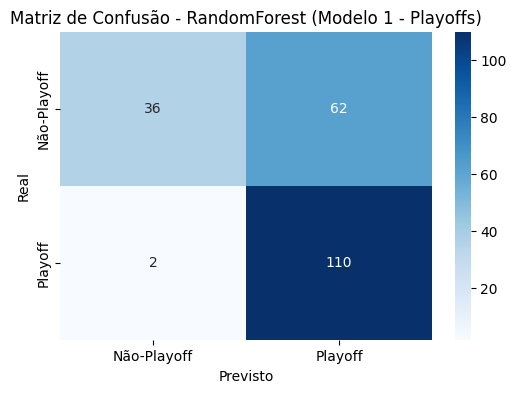

In [24]:
# --- Modelo 1.1: RandomForestClassifier ---
print("\n--- Treinando RandomForestClassifier (Modelo 1) ---")
# Considerar class_weight='balanced' se houver desbalanceamento, mas para playoffs geralmente é menos severo
rf_model_m1 = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=5)
rf_model_m1.fit(X_train_playoffs, y_train_playoffs)

print("\nAvaliando RandomForestClassifier no conjunto de teste (Modelo 1)...")
y_pred_rf_m1 = rf_model_m1.predict(X_test_playoffs)
y_prob_rf_m1 = rf_model_m1.predict_proba(X_test_playoffs)[:, 1] # Probabilidades para classe 1 (Playoffs)

accuracy_rf_m1 = accuracy_score(y_test_playoffs, y_pred_rf_m1)
roc_auc_rf_m1 = roc_auc_score(y_test_playoffs, y_prob_rf_m1)
report_rf_m1 = classification_report(y_test_playoffs, y_pred_rf_m1)
cm_rf_m1 = confusion_matrix(y_test_playoffs, y_pred_rf_m1)

print(f"Acurácia (RandomForest - M1): {accuracy_rf_m1:.4f}")
print(f"ROC AUC (RandomForest - M1): {roc_auc_rf_m1:.4f}")
print("Relatório de Classificação (RandomForest - M1):\n", report_rf_m1)

# Plotar Matriz de Confusão para RandomForest (Modelo 1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_m1, annot=True, fmt='d', cmap='Blues', xticklabels=["Não-Playoff", "Playoff"], yticklabels=["Não-Playoff", "Playoff"])
plt.title("Matriz de Confusão - RandomForest (Modelo 1 - Playoffs)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()




--- Importância das Features (RandomForest - Modelo 1) ---
               Feature  Importance
15                FG %   14.686682
9              Assists   10.416305
7   Defensive Rebounds    9.728249
8             Rebounds    6.349236
12           Turnovers    6.249993
16           3-Pt FG %    5.994199
14       Points Scored    5.945305
10              Steals    5.484106
1          FG Attempts    4.647244
13      Personal Fouls    3.915823
4              FT Made    3.830786
0              FG Made    3.701382
17                FT %    3.496153
5          FT Attempts    3.237327
3     3-Pt FG Attempts    3.208508
2         3-Pt FG Made    3.183454
11              Blocks    2.987528
6   Offensive Rebounds    2.937720


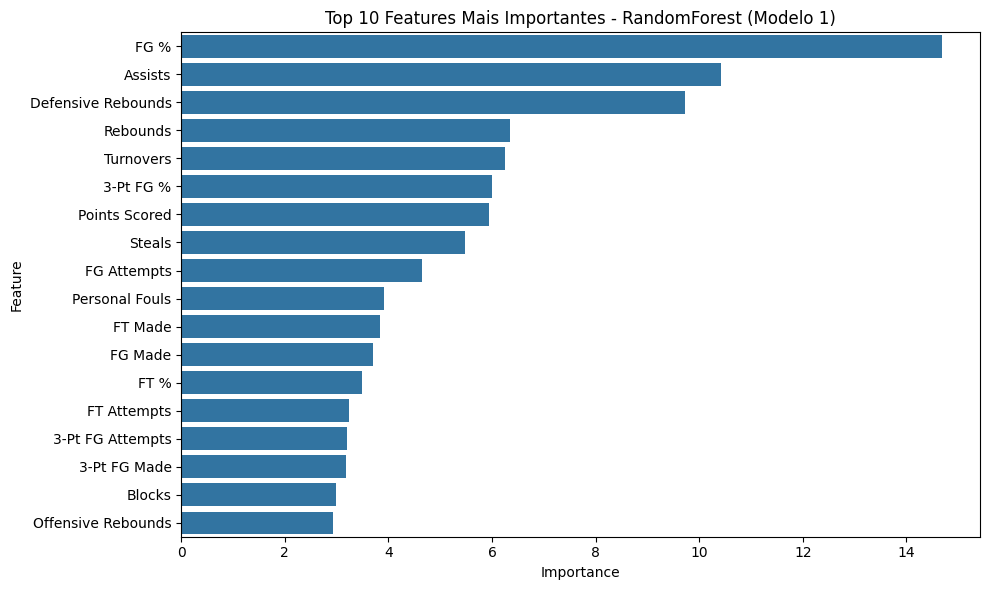


Treinamento e avaliação do Modelo 1 (Playoffs) concluídos.


In [25]:
# --- Feature Importance (Exemplo com RandomForest - Modelo 1) ---
print("\n--- Importância das Features (RandomForest - Modelo 1) ---")
importances_m1 = rf_model_m1.feature_importances_
feature_importance_df_m1 = pd.DataFrame({
    'Feature': X_train_playoffs.columns,
    'Importance': importances_m1 * 100  # transforma em percentual
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df_m1) # Mostrar as 10 mais importantes

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_m1)
plt.title("Top 10 Features Mais Importantes - RandomForest (Modelo 1)")
plt.tight_layout()
plt.show()

print("\nTreinamento e avaliação do Modelo 1 (Playoffs) concluídos.")




--- Treinando LGBMClassifier (Modelo 1) ---

Avaliando LGBMClassifier no conjunto de teste (Modelo 1)...
Acurácia (LGBM - M1): 0.6857
ROC AUC (LGBM - M1): 0.8144
Relatório de Classificação (LGBM - M1):
               precision    recall  f1-score   support

           0       0.92      0.36      0.51        98
           1       0.63      0.97      0.77       112

    accuracy                           0.69       210
   macro avg       0.78      0.67      0.64       210
weighted avg       0.77      0.69      0.65       210



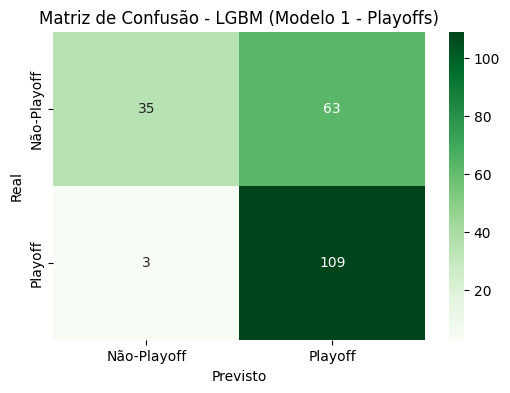


--- Importância das Features (RandomForest - Modelo 1) ---
               Feature  Importance
15                FG %   14.686682
9              Assists   10.416305
7   Defensive Rebounds    9.728249
8             Rebounds    6.349236
12           Turnovers    6.249993
16           3-Pt FG %    5.994199
14       Points Scored    5.945305
10              Steals    5.484106
1          FG Attempts    4.647244
13      Personal Fouls    3.915823
4              FT Made    3.830786
0              FG Made    3.701382
17                FT %    3.496153
5          FT Attempts    3.237327
3     3-Pt FG Attempts    3.208508
2         3-Pt FG Made    3.183454
11              Blocks    2.987528
6   Offensive Rebounds    2.937720


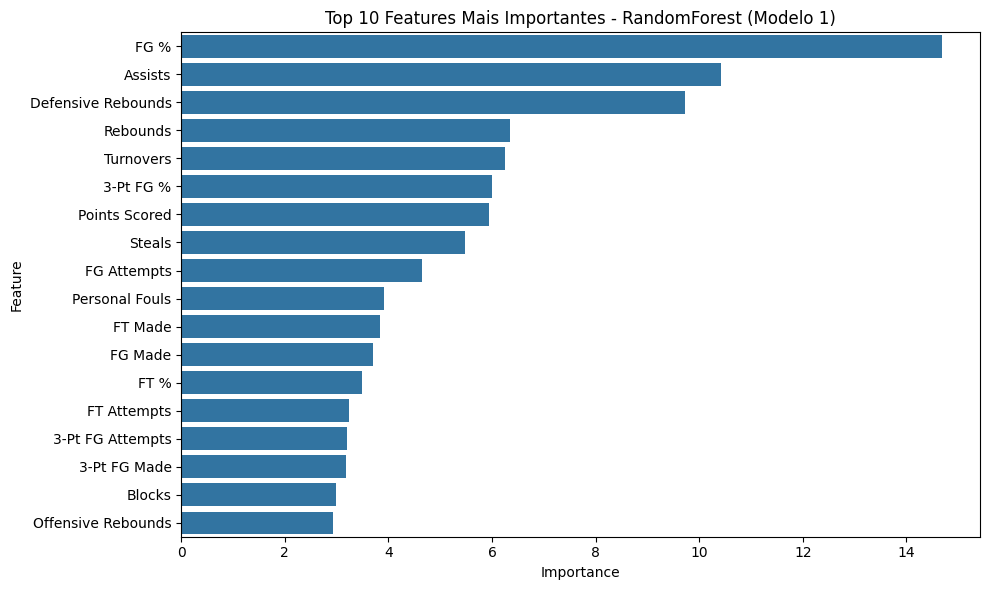


Treinamento e avaliação do Modelo 1 (Playoffs) concluídos.


In [26]:
# --- Modelo 1.2: LGBMClassifier ---
print("\n--- Treinando LGBMClassifier (Modelo 1) ---")
lgbm_model_m1 = lgb.LGBMClassifier(random_state=42, class_weight='balanced', n_estimators=150, max_depth=10, learning_rate=0.05, verbose=-1)
lgbm_model_m1.fit(X_train_playoffs, y_train_playoffs)

print("\nAvaliando LGBMClassifier no conjunto de teste (Modelo 1)...")
y_pred_lgbm_m1 = lgbm_model_m1.predict(X_test_playoffs)
y_prob_lgbm_m1 = lgbm_model_m1.predict_proba(X_test_playoffs)[:, 1]

accuracy_lgbm_m1 = accuracy_score(y_test_playoffs, y_pred_lgbm_m1)
roc_auc_lgbm_m1 = roc_auc_score(y_test_playoffs, y_prob_lgbm_m1)
report_lgbm_m1 = classification_report(y_test_playoffs, y_pred_lgbm_m1)
cm_lgbm_m1 = confusion_matrix(y_test_playoffs, y_pred_lgbm_m1)

print(f"Acurácia (LGBM - M1): {accuracy_lgbm_m1:.4f}")
print(f"ROC AUC (LGBM - M1): {roc_auc_lgbm_m1:.4f}")
print("Relatório de Classificação (LGBM - M1):\n", report_lgbm_m1)

# Plotar Matriz de Confusão para LGBM (Modelo 1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm_m1, annot=True, fmt='d', cmap='Greens', xticklabels=["Não-Playoff", "Playoff"], yticklabels=["Não-Playoff", "Playoff"])
plt.title("Matriz de Confusão - LGBM (Modelo 1 - Playoffs)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# --- Feature Importance (Exemplo com RandomForest - Modelo 1) ---
print("\n--- Importância das Features (RandomForest - Modelo 1) ---")
importances_m1 = lgbm_model_m1.feature_importances_
feature_importance_lgbm_model_m1 = pd.DataFrame({
    'Feature': X_train_playoffs.columns,
    'Importance': importances_m1
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df_m1) # Mostrar as 10 mais importantes

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_m1)
plt.title("Top 10 Features Mais Importantes - RandomForest (Modelo 1)")
plt.tight_layout()
plt.show()

# --- Próximos Passos ---
# 1. Analisar os resultados do Modelo 1: Qual modelo performou melhor na previsão de playoffs?
# 2. Preparar os dados para o Modelo 2: Filtrar df_teams_agg_regular para incluir apenas times que foram aos playoffs (y_test_playoffs == 1 ou usando a lista original de times de playoff).
# 3. Definir o alvo para o Modelo 2: A coluna 'Champion' (0 ou 1) nesse subset de dados.
# 4. Treinar e avaliar modelos (como Gradient Boosting) para o Modelo 2.

print("\nTreinamento e avaliação do Modelo 1 (Playoffs) concluídos.")



In [27]:
# filtrar apenas os dados da temporada regular dos times que foram para os playoffs
df_playoff_teams_only = df_regular_season_agrupado[df_regular_season_agrupado['Playoff Status'] == 1]


### Modelo Campeão NBA

In [28]:
# base do código https://poe.com/s/xZkViIKjdKMl70qZ5D1O
# Definir o ano de corte para treino/teste
# Usaremos as mesmas métricas da temporada regular como features
cutoff_year = 2015

# Dividir os dados com base no ano da temporada
train_data = df_playoff_teams_only[df_playoff_teams_only['Season Start Year'] <= cutoff_year]
test_data = df_playoff_teams_only[df_playoff_teams_only['Season Start Year'] > cutoff_year]

# Separar as features (X) e o target (y)
X_train_champion = train_data[metrics_model_1]
y_train_champion = train_data['Champion']
X_test_champion = test_data[metrics_model_1]
y_test_champion = test_data['Champion']

# Verificar as dimensões dos conjuntos de treino e teste
print(f"Conjunto de treino: {X_train_champion.shape[0]} linhas, {X_train_champion.shape[1]} colunas")
print(f"Conjunto de teste: {X_test_champion.shape[0]} linhas, {X_test_champion.shape[1]} colunas")

Conjunto de treino: 417 linhas, 18 colunas
Conjunto de teste: 112 linhas, 18 colunas


In [29]:
# df_playoff_teams_only.to_excel(r'C:\Users\aoliveira_esss\Downloads\df_playoff_teams_only.xlsx', index=False)



--- Treinando GradientBoostingClassifier (Modelo 2) ---

Avaliando GradientBoostingClassifier no conjunto de teste (Modelo 2)...
Acurácia (Gradient Boosting - M2): 0.8750
ROC AUC (Gradient Boosting - M2): 0.7061
Relatório de Classificação (Gradient Boosting - M2):
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       105
           1       0.18      0.29      0.22         7

    accuracy                           0.88       112
   macro avg       0.57      0.60      0.58       112
weighted avg       0.90      0.88      0.89       112



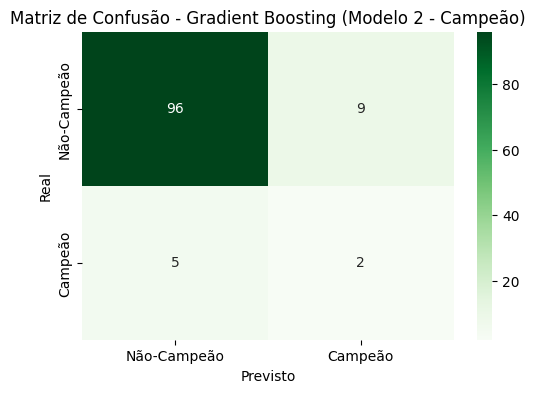


--- Importância das Features (GradientBoostingClassifier - Modelo 2) ---
               Feature  Importance
5          FT Attempts   10.911860
17                FT %    8.649760
15                FG %    8.179778
8             Rebounds    8.075849
12           Turnovers    7.903966
11              Blocks    7.139497
6   Offensive Rebounds    7.137908
2         3-Pt FG Made    5.249760
4              FT Made    5.078917
16           3-Pt FG %    4.192333
1          FG Attempts    4.080687
9              Assists    4.058514
10              Steals    3.692662
13      Personal Fouls    3.247141
3     3-Pt FG Attempts    3.157310
14       Points Scored    3.150553
7   Defensive Rebounds    3.139188
0              FG Made    2.954316


In [33]:
# --- Modelo 2.1: GradientBoostingClassifier ---
print("\n--- Treinando GradientBoostingClassifier (Modelo 2) ---")
# Nota: GradientBoostingClassifier da sklearn não tem `class_weight` direto.
# Poderíamos usar os parâmetros otimizados da busca anterior se disponíveis,
# ou treinar um modelo base.
# Vamos usar um modelo base por enquanto.
gb_model_m2 = GradientBoostingClassifier(n_estimators=150, random_state=42, max_depth=5, learning_rate=0.05, subsample=0.8)
gb_model_m2.fit(X_train_champion, y_train_champion)

print("\nAvaliando GradientBoostingClassifier no conjunto de teste (Modelo 2)...")
y_pred_gb_m2 = gb_model_m2.predict(X_test_champion)
y_prob_gb_m2 = gb_model_m2.predict_proba(X_test_champion)[:, 1]

accuracy_gb_m2 = accuracy_score(y_test_champion, y_pred_gb_m2)
roc_auc_gb_m2 = roc_auc_score(y_test_champion, y_prob_gb_m2)
report_gb_m2 = classification_report(y_test_champion, y_pred_gb_m2)
cm_gb_m2 = confusion_matrix(y_test_champion, y_pred_gb_m2)

print(f"Acurácia (Gradient Boosting - M2): {accuracy_gb_m2:.4f}")
print(f"ROC AUC (Gradient Boosting - M2): {roc_auc_gb_m2:.4f}")
print("Relatório de Classificação (Gradient Boosting - M2):\n", report_gb_m2)

# Plotar Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb_m2, annot=True, fmt='d', cmap='Greens', xticklabels=["Não-Campeão", "Campeão"], yticklabels=["Não-Campeão", "Campeão"])
plt.title("Matriz de Confusão - Gradient Boosting (Modelo 2 - Campeão)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()


# --- Feature Importance (Exemplo com Modelo 2.1: GradientBoostingClassifier) ---
print("\n--- Importância das Features (GradientBoostingClassifier - Modelo 2) ---")
importances_m1 = gb_model_m2.feature_importances_
feature_importance_df_m1 = pd.DataFrame({
    'Feature': X_train_champion.columns,
    'Importance': importances_m1 * 100
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df_m1) # Mostrar as 10 mais importantes



--- Treinando LGBMClassifier (Modelo 2) ---

Avaliando LGBMClassifier no conjunto de teste (Modelo 2)...
Acurácia (LGBM - M2): 0.8661
ROC AUC (LGBM - M2): 0.6735
Relatório de Classificação (LGBM - M2):
               precision    recall  f1-score   support

           0       0.94      0.91      0.93       105
           1       0.10      0.14      0.12         7

    accuracy                           0.87       112
   macro avg       0.52      0.53      0.52       112
weighted avg       0.89      0.87      0.88       112



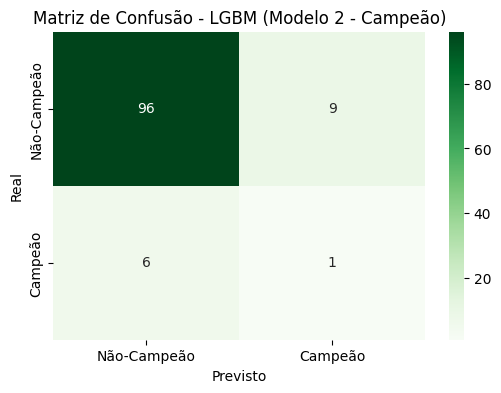


--- Importância das Features (RandomForest - Modelo 1) ---
               Feature  Importance
4              FT Made         230
15                FG %         173
8             Rebounds         157
11              Blocks         145
5          FT Attempts         131
17                FT %         123
6   Offensive Rebounds          96
10              Steals          83
13      Personal Fouls          82
9              Assists          79
12           Turnovers          73
16           3-Pt FG %          66
0              FG Made          51
14       Points Scored          48
7   Defensive Rebounds          40
1          FG Attempts          38
2         3-Pt FG Made          32
3     3-Pt FG Attempts          21


In [31]:
# --- Modelo 2.2: LGBMClassifier ---
print("\n--- Treinando LGBMClassifier (Modelo 2) ---")
lgbm_model_m2 = lgb.LGBMClassifier(random_state=42, class_weight='balanced', n_estimators=150, max_depth=5, learning_rate=0.05)
lgbm_model_m2.fit(X_train_champion, y_train_champion)

print("\nAvaliando LGBMClassifier no conjunto de teste (Modelo 2)...")
y_pred_lgbm_m2 = lgbm_model_m2.predict(X_test_champion)
y_prob_lgbm_m2 = lgbm_model_m2.predict_proba(X_test_champion)[:, 1]

accuracy_lgbm_m2 = accuracy_score(y_test_champion, y_pred_lgbm_m2)
roc_auc_lgbm_m2 = roc_auc_score(y_test_champion, y_prob_lgbm_m2)
report_lgbm_m2 = classification_report(y_test_champion, y_pred_lgbm_m2)
cm_lgbm_m2 = confusion_matrix(y_test_champion, y_pred_lgbm_m2)

print(f"Acurácia (LGBM - M2): {accuracy_lgbm_m2:.4f}")
print(f"ROC AUC (LGBM - M2): {roc_auc_lgbm_m2:.4f}")
print("Relatório de Classificação (LGBM - M2):\n", report_lgbm_m2)

# Plotar Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm_m2, annot=True, fmt='d', cmap='Greens', xticklabels=["Não-Campeão", "Campeão"], yticklabels=["Não-Campeão", "Campeão"])
plt.title("Matriz de Confusão - LGBM (Modelo 2 - Campeão)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()

# --- Feature Importance (Exemplo com RandomForest - Modelo 1) ---
print("\n--- Importância das Features (RandomForest - Modelo 1) ---")
importances_m1 = lgbm_model_m2.feature_importances_
feature_importance_df_m1 = pd.DataFrame({
    'Feature': X_train_champion.columns,
    'Importance': importances_m1
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df_m1) # Mostrar as 10 mais importantes



Calculado scale_pos_weight para XGBoost: 15.68

--- Treinando XGBClassifier (Modelo 2) ---

Avaliando XGBClassifier no conjunto de teste (Modelo 2)...
Acurácia (XGBoost - M2): 0.8929
ROC AUC (XGBoost - M2): 0.6898
Relatório de Classificação (XGBoost - M2):
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       105
           1       0.14      0.14      0.14         7

    accuracy                           0.89       112
   macro avg       0.54      0.54      0.54       112
weighted avg       0.89      0.89      0.89       112



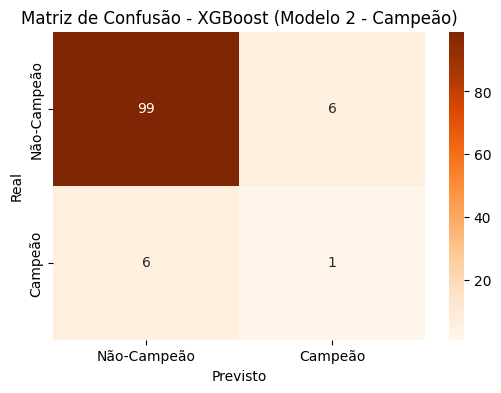


--- Importância das Features (Treinando XGBClassifier (Modelo 2)) ---
               Feature  Importance
5          FT Attempts    0.082467
4              FT Made    0.076566
17                FT %    0.070369
10              Steals    0.064887
11              Blocks    0.061569
15                FG %    0.060153
8             Rebounds    0.058700
13      Personal Fouls    0.058579
1          FG Attempts    0.054682
7   Defensive Rebounds    0.051558
14       Points Scored    0.049316
6   Offensive Rebounds    0.048874
0              FG Made    0.047702
12           Turnovers    0.047101
3     3-Pt FG Attempts    0.043748
2         3-Pt FG Made    0.041783
16           3-Pt FG %    0.041529
9              Assists    0.040418

Treinamento e avaliação do Modelo 2 (Campeão) concluídos.


In [32]:
# --- Modelo 2.3: XGBClassifier ---
# Calcular scale_pos_weight para XGBoost (opcional, mas recomendado para desbalanceamento)
# scale_pos_weight = count(negative class) / count(positive class)
neg_count = np.sum(y_train_champion == 0)
pos_count = np.sum(y_train_champion == 1)
scale_pos_weight_value = neg_count / pos_count if pos_count > 0 else 1
print(f"Calculado scale_pos_weight para XGBoost: {scale_pos_weight_value:.2f}")


print("\n--- Treinando XGBClassifier (Modelo 2) ---")
xgb_model_m2 = XGBClassifier(random_state=42, n_estimators=150, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, verbosity=0, scale_pos_weight=scale_pos_weight_value)
xgb_model_m2.fit(X_train_champion, y_train_champion)

print("\nAvaliando XGBClassifier no conjunto de teste (Modelo 2)...")
y_pred_xgb_m2 = xgb_model_m2.predict(X_test_champion)
y_prob_xgb_m2 = xgb_model_m2.predict_proba(X_test_champion)[:, 1]

accuracy_xgb_m2 = accuracy_score(y_test_champion, y_pred_xgb_m2)
roc_auc_xgb_m2 = roc_auc_score(y_test_champion, y_prob_xgb_m2)
report_xgb_m2 = classification_report(y_test_champion, y_pred_xgb_m2)
cm_xgb_m2 = confusion_matrix(y_test_champion, y_pred_xgb_m2)

print(f"Acurácia (XGBoost - M2): {accuracy_xgb_m2:.4f}")
print(f"ROC AUC (XGBoost - M2): {roc_auc_xgb_m2:.4f}")
print("Relatório de Classificação (XGBoost - M2):\n", report_xgb_m2)

# Plotar Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_m2, annot=True, fmt='d', cmap='Oranges', xticklabels=["Não-Campeão", "Campeão"], yticklabels=["Não-Campeão", "Campeão"])
plt.title("Matriz de Confusão - XGBoost (Modelo 2 - Campeão)")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.show()


print("\n--- Importância das Features (Treinando XGBClassifier (Modelo 2)) ---")
importances_m1 = xgb_model_m2.feature_importances_
feature_importance_df_m1 = pd.DataFrame({
    'Feature': X_train_champion.columns,
    'Importance': importances_m1
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df_m1) 

print("\nTreinamento e avaliação do Modelo 2 (Campeão) concluídos.")
